# 03 - Marked Events and Online Estimation

Two extensions that matter in practice:

1. **Marked processes** attach a value (a *mark*) to each event -- an
   earthquake magnitude, a trade size, a tweet's follower count -- and let
   larger marks trigger more offspring. The intensity becomes
   $\lambda(t) = \mu + \sum_{t_i<t} g(m_i)\,\varphi(t-t_i)$ with a mark-influence
   function $g$.
2. **Online estimation** updates parameters event-by-event from a stream,
   instead of refitting a whole batch -- essential for real-time monitoring.

*Builds on 01.*

In [1]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt

import intensify as it

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.dpi": 110, "font.size": 11, "axes.titlesize": 13})

rng = np.random.default_rng(0)
print(f"intensify {it.__version__}")

intensify 0.3.3


## Part A - Marked Hawkes

### 1. Simulate marked events
Marks are drawn from a heavy-tailed distribution; `mark_influence="power"`
with `mark_power=p` sets $g(m) = m^{p}$, so rare large marks dominate triggering.

In [2]:
T = 1000.0
MARK_POWER_TRUE = 1.5

marked = it.MarkedHawkes(
    mu=0.20,
    kernel=it.ExponentialKernel(alpha=0.25, beta=0.5),
    mark_influence="power",
    mark_power=MARK_POWER_TRUE,
    simulate_marks=lambda rng, n: rng.lognormal(mean=0.0, sigma=0.6, size=n),
)
times, marks = marked.simulate(T=T, seed=3)
times, marks = np.asarray(times), np.asarray(marks)
print(f"{len(times)} events; mark median={np.median(marks):.2f}, max={marks.max():.2f}")

354 events; mark median=1.02, max=4.50


### 2. Events coloured by mark

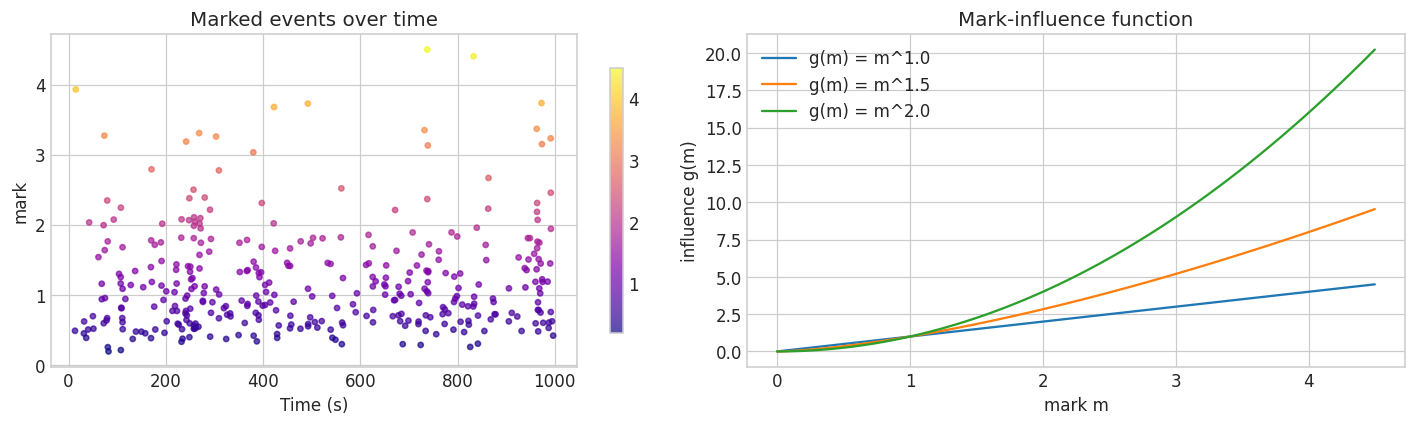

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sc = axes[0].scatter(times, marks, c=marks, cmap="plasma", s=12, alpha=0.7)
axes[0].set_xlabel("Time (s)"); axes[0].set_ylabel("mark")
axes[0].set_title("Marked events over time"); fig.colorbar(sc, ax=axes[0], shrink=0.8)

mg = np.linspace(0, marks.max(), 100)
for p in (1.0, 1.5, 2.0):
    axes[1].plot(mg, mg ** p, label=f"g(m) = m^{p}")
axes[1].set_xlabel("mark m"); axes[1].set_ylabel("influence g(m)")
axes[1].set_title("Mark-influence function"); axes[1].legend()
fig.tight_layout(); plt.show()

### 3. Selecting the mark sensitivity by profile likelihood
`MarkedHawkes.fit` accepts `(events, marks)` and estimates $\mu$ and the kernel
by MLE. The mark exponent `mark_power` is a *hyperparameter* of the influence
function, not part of the inner optimisation -- so we recover it the standard
way: fit at a grid of values and pick the one with the best likelihood
(**profile likelihood**).

In [4]:
powers = [0.5, 1.0, 1.5, 2.0, 2.5]
scan = []
print(f"{'mark_power':>10}{'loglik':>10}{'AIC':>10}")
for p in powers:
    m = it.MarkedHawkes(mu=0.2, kernel=it.ExponentialKernel(alpha=0.2, beta=0.4),
                        mark_influence="power", mark_power=p)
    r = m.fit(times, marks, T=T, method="mle")
    scan.append((p, r))
    print(f"{p:>10.1f}{r.log_likelihood:>10.1f}{r.aic:>10.1f}")

best_p, mk_res = min(scan, key=lambda s: s[1].aic)
print(f"\nprofile likelihood selects mark_power = {best_p}  (true {MARK_POWER_TRUE})")

mark_power    loglik       AIC
       0.5    -679.2    1364.5
       1.0    -674.7    1355.4
       1.5    -673.3    1352.5
       2.0    -674.4    1354.8
       2.5    -677.3    1360.6

profile likelihood selects mark_power = 1.5  (true 1.5)


Now compare the best marked model with an unmarked Hawkes that ignores the
marks: the marked model should win on AIC because the marks carry real
triggering information.

In [5]:
un_fit = it.UnivariateHawkes(mu=0.2, kernel=it.ExponentialKernel(alpha=0.2, beta=0.4))
un_res = un_fit.fit(times, T=T, method="mle")
print(f"{'model':<24}{'loglik':>10}{'AIC':>10}")
print(f"{f'marked (p={best_p})':<24}{mk_res.log_likelihood:>10.1f}{mk_res.aic:>10.1f}")
print(f"{'unmarked':<24}{un_res.log_likelihood:>10.1f}{un_res.aic:>10.1f}")
print(f"\nDelta AIC (unmarked - marked) = {un_res.aic - mk_res.aic:.1f} "
      f"-> {'marked preferred' if un_res.aic > mk_res.aic else 'unmarked preferred'}")

model                       loglik       AIC
marked (p=1.5)              -673.3    1352.5
unmarked                    -686.6    1377.2

Delta AIC (unmarked - marked) = 24.6 -> marked preferred


## Part B - Online (streaming) estimation

`OnlineInference` performs sliding-window stochastic-gradient updates on the
recursive Hawkes likelihood. Each `update(process, t)` ingests one event and
nudges the parameters -- no full refit. We replay a stream and watch the
estimates converge toward the batch MLE.

*(Online estimation supports univariate Hawkes with a recursive-form kernel,
e.g. the exponential kernel.)*

In [6]:
TS = 2000.0
true_stream = it.UnivariateHawkes(mu=0.4, kernel=it.ExponentialKernel(alpha=0.4, beta=1.0))
stream = np.asarray(true_stream.simulate(T=TS, seed=21))
print(f"streaming {len(stream)} events")

# Batch MLE for reference
batch = it.UnivariateHawkes(mu=0.3, kernel=it.ExponentialKernel(alpha=0.3, beta=1.2))
batch_p = batch.fit(stream, T=TS, method="mle").flat_params()
print("batch MLE:", {k: round(batch_p[k], 3) for k in ("mu", "alpha", "beta")})

streaming 1376 events
batch MLE: {'mu': 0.411, 'alpha': 0.404, 'beta': 0.861}


In [7]:
engine = it.OnlineInference(lr=1e-3, min_events=50)
proc = it.UnivariateHawkes(mu=0.3, kernel=it.ExponentialKernel(alpha=0.3, beta=1.2))
engine.reset()

# After each update the estimates live on the process itself.
traj = {"mu": [], "alpha": [], "beta": []}
for t in stream:
    engine.update(proc, float(t))
    traj["mu"].append(proc.mu)
    traj["alpha"].append(proc.kernel.alpha)
    traj["beta"].append(proc.kernel.beta)
print("online final:", {k: round(traj[k][-1], 3) for k in traj})

online final: {'mu': 0.409, 'alpha': 0.406, 'beta': 0.842}


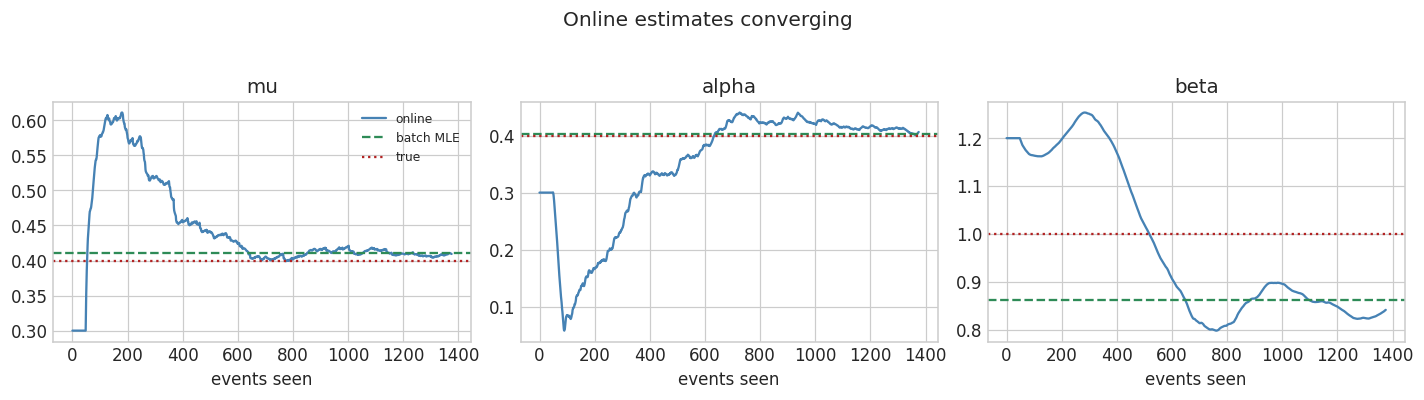

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
truth = {"mu": 0.4, "alpha": 0.4, "beta": 1.0}
for ax, k in zip(axes, ("mu", "alpha", "beta")):
    ax.plot(traj[k], color="steelblue", label="online")
    ax.axhline(batch_p[k], color="seagreen", ls="--", label="batch MLE")
    ax.axhline(truth[k], color="firebrick", ls=":", label="true")
    ax.set_title(k); ax.set_xlabel("events seen")
axes[0].legend(fontsize=8)
fig.suptitle("Online estimates converging", y=1.03)
fig.tight_layout(); plt.show()

### Real-time intensity tracking
As parameters settle, the running model's intensity tracks the live stream --
the basis for streaming anomaly/burst detection.

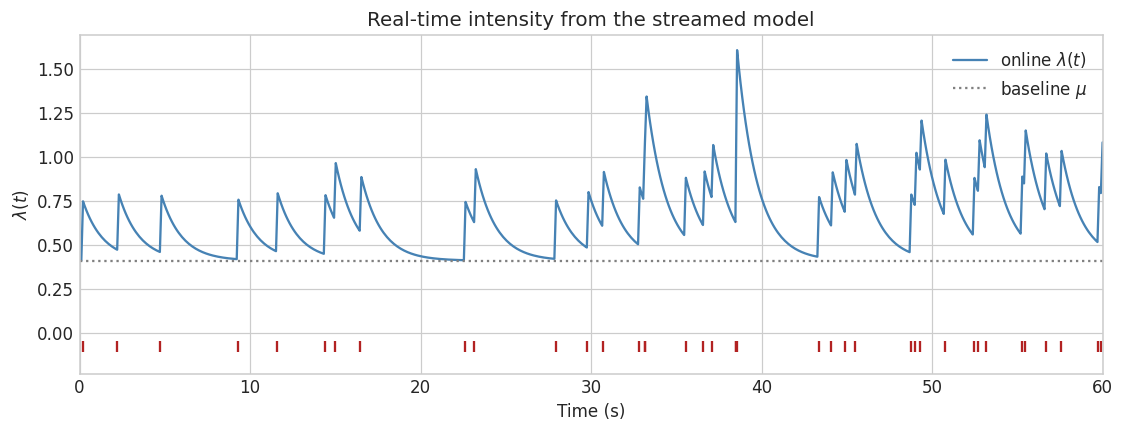

In [9]:
win = (0.0, 60.0)
seg = stream[(stream >= win[0]) & (stream <= win[1])]
grid = np.linspace(win[0] + 1e-3, win[1], 600)
lam = [float(proc.intensity(t, stream[stream < t])) for t in grid]

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(grid, lam, color="steelblue", label=r"online $\lambda(t)$")
ax.eventplot(seg, lineoffsets=-0.05 * max(lam), linelengths=0.04 * max(lam),
             colors="firebrick")
ax.axhline(proc.mu, color="gray", ls=":", label=r"baseline $\mu$")
ax.set_xlim(*win); ax.set_xlabel("Time (s)"); ax.set_ylabel(r"$\lambda(t)$")
ax.set_title("Real-time intensity from the streamed model"); ax.legend()
plt.show()

---
### Try it yourself
* Make marks heavier-tailed (raise `sigma`) and watch `mark_power` matter more.
* Tune the online `lr` / `forgetting_factor` and observe the convergence/jitter
  trade-off.
* Feed a process whose parameters *drift* mid-stream and see the online
  estimator adapt where a single batch fit cannot.

### Next steps
* **04_connectivity_and_nonlinear** -- inhibition, nonparametric kernels,
  sparsity.
* User guide: [inference](../docs/user_guide/inference.md),
  [simulation](../docs/user_guide/simulation.md).